In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
# Load sensor data
secom = pd.read_csv(
    '/home/jupyter/secom-yield-optimization/data/raw/secom.data',
    sep=' ',        # columns are space-separated
    header=None     # no column headers in the file
)

# Load labels
labels = pd.read_csv(
    '/home/jupyter/secom-yield-optimization/data/raw/secom_labels.data',
    sep=' ',
    header=None,
    names=['label', 'timestamp']
)

print(f"Sensor data shape: {secom.shape}")
print(f"Labels shape:      {labels.shape}")

# Check the RAW label values BEFORE any mapping
print("Raw label values and counts:")
print(labels['label'].value_counts())
print(f"\nUnique values in label column: {labels['label'].unique()}")

Sensor data shape: (1567, 590)
Labels shape:      (1567, 2)
Raw label values and counts:
label
-1    1463
 1     104
Name: count, dtype: int64

Unique values in label column: [-1  1]


In [3]:
# Give each sensor column a name: sensor_1, sensor_2, ... sensor_590
secom.columns = [f'sensor_{i+1}' for i in range(secom.shape[1])]
combined_df = pd.concat([secom, labels], axis=1)

In [4]:
# Look at the first 5 rows
cols_to_show = [f'sensor_{i}' for i in range(1, 11)] + ['label', 'timestamp']
combined_df[cols_to_show].head()

,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,label,timestamp
0,3030.9300,2564.0000,2187.7333,1411.1265,1.3602,100.0000,97.6133,0.1242,1.5005,0.0162,-1,19/07/2008 11:55:00
1,3095.7800,2465.1400,2230.4222,1463.6606,0.8294,100.0000,102.3433,0.1247,1.4966,-0.0005,-1,19/07/2008 12:32:00
2,2932.6100,2559.9400,2186.4111,1698.0172,1.5102,100.0000,95.4878,0.1241,1.4436,0.0041,1,19/07/2008 13:17:00
3,2988.7200,2479.9000,2199.0333,909.7926,1.3204,100.0000,104.2367,0.1217,1.4882,-0.0124,-1,19/07/2008 14:43:00
4,3032.2400,2502.8700,2233.3667,1326.5200,1.5334,100.0000,100.3967,0.1235,1.5031,-0.0031,-1,19/07/2008 15:22:00


In [5]:
# 1=pass→0, -1=fail→1
# fail=1 (positive class) and pass=0 (negative class)
labels['label'] = labels['label'].map({-1: 0, 1: 1})

# Join sensor data and labels side by side into one dataframe
df = pd.concat([secom, labels], axis=1)

print(f"Combined dataframe shape: {df.shape}")
print(f"\nLabel distribution:")
print(df['label'].value_counts())
print(f"\nFailure rate: {df['label'].mean()*100:.2f}%")

Combined dataframe shape: (1567, 592)

Label distribution:
label
0    1463
1     104
Name: count, dtype: int64

Failure rate: 6.64%


In [6]:
# Look at the first 5 rows
cols_to_show = [f'sensor_{i}' for i in range(1, 11)] + ['label', 'timestamp']
df[cols_to_show].head()

,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,label,timestamp
0,3030.9300,2564.0000,2187.7333,1411.1265,1.3602,100.0000,97.6133,0.1242,1.5005,0.0162,0,19/07/2008 11:55:00
1,3095.7800,2465.1400,2230.4222,1463.6606,0.8294,100.0000,102.3433,0.1247,1.4966,-0.0005,0,19/07/2008 12:32:00
2,2932.6100,2559.9400,2186.4111,1698.0172,1.5102,100.0000,95.4878,0.1241,1.4436,0.0041,1,19/07/2008 13:17:00
3,2988.7200,2479.9000,2199.0333,909.7926,1.3204,100.0000,104.2367,0.1217,1.4882,-0.0124,0,19/07/2008 14:43:00
4,3032.2400,2502.8700,2233.3667,1326.5200,1.5334,100.0000,100.3967,0.1235,1.5031,-0.0031,0,19/07/2008 15:22:00


In [7]:
# How many missing values exist across the entire dataset?
total_cells = df.shape[0] * df.shape[1]
missing_cells = df.isnull().sum().sum()

# What percentage of the sensor columns have at least one missing value?
sensors_with_missing = df[[f'sensor_{i}' for i in range(1, 591)]].isnull().any().sum()

print(f"Total cells:            {total_cells:,}")
print(f"Missing cells:          {missing_cells:,}")
print(f"Overall missing rate:   {missing_cells/total_cells*100:.2f}%")
print(f"\nSensors with at least one missing value: {sensors_with_missing} out of 590")

Total cells:            927,664
Missing cells:          41,951
Overall missing rate:   4.52%

Sensors with at least one missing value: 538 out of 590


In [8]:
# Calculate missing rate for each sensor column
sensor_cols = [f'sensor_{i}' for i in range(1, 591)]
missing_per_sensor = df[sensor_cols].isnull().mean() * 100

# Bin sensors by how much data they're missing
bins = [0, 1, 10, 30, 50, 100]
labels_bins = ['<1%', '1-10%', '10-30%', '30-50%', '>50%']
missing_binned = pd.cut(missing_per_sensor, bins=bins, labels=labels_bins)

print("Sensors grouped by missing rate:")
print(missing_binned.value_counts().sort_index())
print(f"\nSensors with >50% missing: {(missing_per_sensor > 50).sum()}")
print(f"Sensors with >90% missing: {(missing_per_sensor > 90).sum()}")

Sensors grouped by missing rate:
<1%       435
1-10%      51
10-30%     20
30-50%      4
>50%       28
Name: count, dtype: int64

Sensors with >50% missing: 28
Sensors with >90% missing: 4


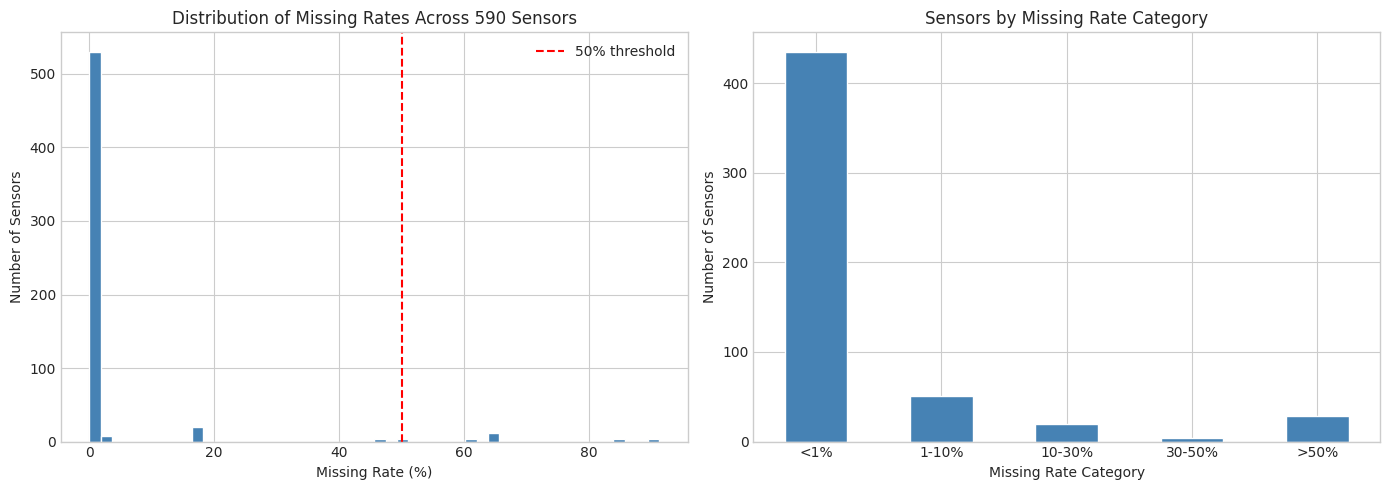

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: histogram of missing rates across all sensors
axes[0].hist(missing_per_sensor, bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Missing Rate (%)')
axes[0].set_ylabel('Number of Sensors')
axes[0].set_title('Distribution of Missing Rates Across 590 Sensors')
axes[0].axvline(x=50, color='red', linestyle='--', label='50% threshold')
axes[0].legend()

# Right plot: bar chart of binned missing rates
missing_binned.value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='white'
)
axes[1].set_xlabel('Missing Rate Category')
axes[1].set_ylabel('Number of Sensors')
axes[1].set_title('Sensors by Missing Rate Category')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('/home/jupyter/secom-yield-optimization/data/processed/missing_data_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Step 1: Identify and drop sensors with >40% missing data
sensors_to_drop = missing_per_sensor[missing_per_sensor > 40].index.tolist()

print(f"Dropping {len(sensors_to_drop)} sensors with >40% missing data")
print(f"Sensors dropped: {sensors_to_drop}")

# Remove them from the dataframe
df_cleaned = df.drop(columns=sensors_to_drop)

# How many sensor columns remain?
remaining_sensors = [c for c in df_cleaned.columns if c.startswith('sensor_')]
print(f"\nSensors remaining after drop: {len(remaining_sensors)}")

Dropping 32 sensors with >40% missing data
Sensors dropped: ['sensor_73', 'sensor_74', 'sensor_86', 'sensor_110', 'sensor_111', 'sensor_112', 'sensor_113', 'sensor_158', 'sensor_159', 'sensor_221', 'sensor_245', 'sensor_246', 'sensor_247', 'sensor_248', 'sensor_293', 'sensor_294', 'sensor_346', 'sensor_347', 'sensor_359', 'sensor_383', 'sensor_384', 'sensor_385', 'sensor_386', 'sensor_493', 'sensor_517', 'sensor_518', 'sensor_519', 'sensor_520', 'sensor_579', 'sensor_580', 'sensor_581', 'sensor_582']

Sensors remaining after drop: 558


In [11]:
from sklearn.feature_selection import VarianceThreshold

sensor_cols_remaining = [c for c in df_cleaned.columns if c.startswith('sensor_')]

# Remove zero variance sensors BEFORE imputation
# so flat sensors are caught on real observed values
selector = VarianceThreshold(threshold=0)
selector.fit(df_cleaned[sensor_cols_remaining])

sensors_kept = [col for col, kept in 
                zip(sensor_cols_remaining, selector.get_support()) if kept]
sensors_removed_var = [col for col, kept in 
                       zip(sensor_cols_remaining, selector.get_support()) if not kept]

print(f"Sensors before variance filter: {len(sensor_cols_remaining)}")
print(f"Zero variance sensors removed:  {len(sensors_removed_var)}")
print(f"Sensors remaining:              {len(sensors_kept)}")

# Apply the filter
df_cleaned = df_cleaned[sensors_kept + ['label', 'timestamp']]
print(f"\nDataframe shape after variance filter: {df_cleaned.shape}")

Sensors before variance filter: 558
Zero variance sensors removed:  116
Sensors remaining:              442

Dataframe shape after variance filter: (1567, 444)


In [12]:
from sklearn.impute import KNNImputer

# Sensor columns after variance filter
sensor_cols_remaining = [c for c in df_cleaned.columns if c.startswith('sensor_')]

imputer = KNNImputer(
    n_neighbors=5,
    weights='distance',
    metric='nan_euclidean'
)

print("Running KNN imputation....")

df_cleaned[sensor_cols_remaining] = imputer.fit_transform(
    df_cleaned[sensor_cols_remaining]
)

remaining_missing = df_cleaned[sensor_cols_remaining].isnull().sum().sum()
print(f"\nMissing values after imputation: {remaining_missing}")
print(f"Dataframe shape after imputation: {df_cleaned.shape}")

Running KNN imputation....

Missing values after imputation: 0
Dataframe shape after imputation: (1567, 444)


In [13]:
# Run variance filter again to catch any sensors
# that became flat after KNN imputation
sensor_cols_remaining = [c for c in df_cleaned.columns if c.startswith('sensor_')]

selector2 = VarianceThreshold(threshold=0)
selector2.fit(df_cleaned[sensor_cols_remaining])

sensors_kept_2 = [col for col, kept in 
                  zip(sensor_cols_remaining, selector2.get_support()) if kept]
sensors_removed_2 = [col for col, kept in 
                     zip(sensor_cols_remaining, selector2.get_support()) if not kept]

print(f"Second variance filter:")
print(f"Sensors removed: {len(sensors_removed_2)}")
if sensors_removed_2:
    print(f"Removed: {sensors_removed_2}")

df_cleaned = df_cleaned[sensors_kept_2 + ['label', 'timestamp']]
print(f"\nFinal dataframe shape: {df_cleaned.shape}")

Second variance filter:
Sensors removed: 0

Final dataframe shape: (1567, 444)


In [14]:
from scipy.stats.mstats import winsorize

sensor_cols_final = [c for c in df_cleaned.columns if c.startswith('sensor_')]

# Winsorize at 1st and 99th percentile
# Applied AFTER imputation so we're working with complete data
# Applied BEFORE saving so Notebook 2 receives clean data
df_cleaned_w = df_cleaned.copy()

for col in sensor_cols_final:
    df_cleaned_w[col] = winsorize(df_cleaned[col], limits=(0.01, 0.01))

# Verify the effect on our known problematic sensors
for col in ['sensor_5', 'sensor_522']:
    if col in df_cleaned_w.columns:
        print(f"{col} BEFORE: max={df_cleaned[col].max():.4f}, std={df_cleaned[col].std():.4f}")
        print(f"{col} AFTER:  max={df_cleaned_w[col].max():.4f}, std={df_cleaned_w[col].std():.4f}")
        print()

# Replace df_cleaned with winsorized version
df_cleaned = df_cleaned_w
print(f"Winsorization complete")
print(f"Dataframe shape unchanged: {df_cleaned.shape}")

sensor_5 BEFORE: max=1114.5366, std=56.1037
sensor_5 AFTER:  max=2.5361, std=0.3875

sensor_522 BEFORE: max=1000.0000, std=103.1230
sensor_522 AFTER:  max=776.2169, std=83.5659

Winsorization complete
Dataframe shape unchanged: (1567, 444)


In [15]:
# Investigate any other sensors with the same pathological pattern
# (mostly zeros with occasional extreme spikes)
sensor_cols_final = [c for c in df_cleaned.columns if c.startswith('sensor_')]

pathological_sensors = []

for col in sensor_cols_final:
    # Flag sensors where 75th percentile is zero but max is large
    q75 = df_cleaned[col].quantile(0.75)
    col_max = df_cleaned[col].max()
    col_std = df_cleaned[col].std()
    
    if q75 == 0 and col_max > 10:
        pathological_sensors.append({
            'sensor': col,
            'q75': q75,
            'max': col_max,
            'std': col_std,
            'pct_zero': (df_cleaned[col] == 0).mean() * 100
        })

path_df = pd.DataFrame(pathological_sensors).sort_values('max', ascending=False)
print(f"Sensors with 75th percentile = 0 and max > 10: {len(pathological_sensors)}")
print(path_df.to_string(index=False))

/opt/conda/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:4842: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/opt/conda/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:4842: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/opt/conda/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:4842: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/opt/conda/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:4842: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/opt/conda/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:4842: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/opt/conda/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:4842: UserWarning: Warning: 'partition' will ignore the 'mask'

Sensors with 75th percentile = 0 and max > 10: 1
    sensor    q75      max     std  pct_zero
sensor_522 0.0000 776.2169 83.5659   98.6599


/opt/conda/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:4842: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/opt/conda/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:4842: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/opt/conda/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:4842: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/opt/conda/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:4842: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/opt/conda/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:4842: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/opt/conda/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:4842: UserWarning: Warning: 'partition' will ignore the 'mask'

In [16]:
# Drop sensor_522 — mostly zero (98.7%) with random extreme spikes
# Not a meaningful continuous process signal
df_cleaned = df_cleaned.drop(columns=['sensor_522'])

# Verify removal
sensor_cols_final = [c for c in df_cleaned.columns if c.startswith('sensor_')]
print(f"sensor_522 removed")
print(f"Sensors remaining: {len(sensor_cols_final)}")
print(f"Final dataframe shape: {df_cleaned.shape}")

sensor_522 removed
Sensors remaining: 441
Final dataframe shape: (1567, 443)


In [17]:


df_final = df_cleaned.copy()

print(f"Final cleaned dataframe shape: {df_final.shape}")

# Save to processed folder as CSV
output_path = '/home/jupyter/secom-yield-optimization/data/processed/secom_cleaned.csv'
df_final.to_csv(output_path, index=False)
print(f"Cleaned data saved to: {output_path}")

# Also save to GCS bucket for backup
import subprocess
result = subprocess.run([
    'gsutil', 'cp', output_path,
    'gs://secom-data-temi/processed/secom_cleaned.csv'
], capture_output=True, text=True)

if result.returncode == 0:
    print("Backup saved to GCS bucket")
else:
    print(f"GCS upload failed: {result.stderr}")

Final cleaned dataframe shape: (1567, 443)
Cleaned data saved to: /home/jupyter/secom-yield-optimization/data/processed/secom_cleaned.csv
Backup saved to GCS bucket


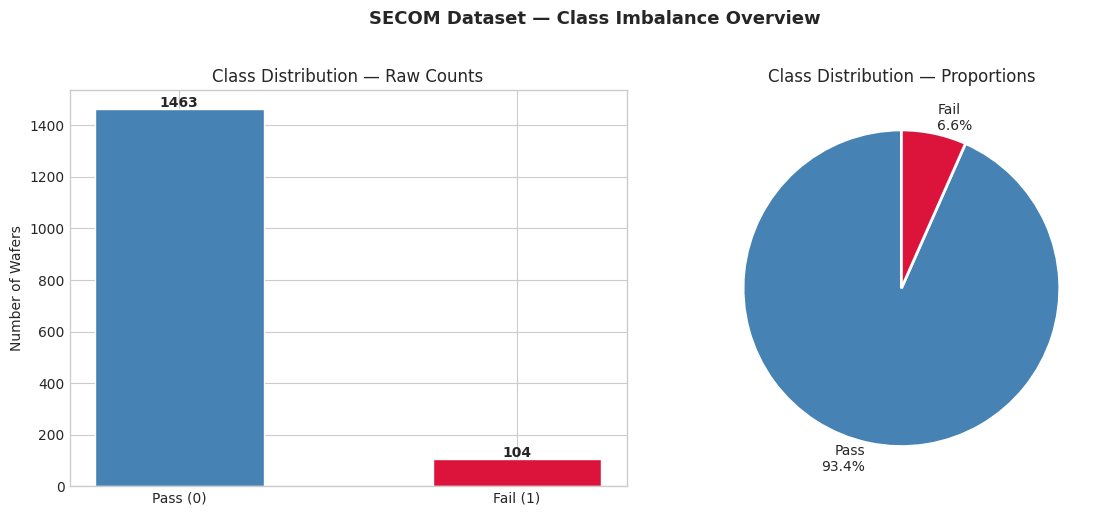

In [18]:
#Visualize class imbalance
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left plot: raw counts
counts = df_final['label'].value_counts()
axes[0].bar(['Pass (0)', 'Fail (1)'], counts.values, 
            color=['steelblue', 'crimson'], edgecolor='white', width=0.5)
axes[0].set_ylabel('Number of Wafers')
axes[0].set_title('Class Distribution — Raw Counts')
for i, v in enumerate(counts.values):
    # Write the count number on top of each bar
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Right plot: percentage
axes[1].pie(counts.values, 
            labels=[f'Pass\n{counts.values[0]/len(df_final)*100:.1f}%', 
                    f'Fail\n{counts.values[1]/len(df_final)*100:.1f}%'],
            colors=['steelblue', 'crimson'],
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Distribution — Proportions')

plt.suptitle('SECOM Dataset — Class Imbalance Overview', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/home/jupyter/secom-yield-optimization/data/processed/class_imbalance.png',
            dpi=150, bbox_inches='tight')
plt.show()


In [19]:
sensor_cols_final = [c for c in df_final.columns if c.startswith('sensor_')]

# Summary statistics for all remaining sensors
sensor_stats = df_final[sensor_cols_final].describe().T

sensor_stats.to_csv(
    '/home/jupyter/secom-yield-optimization/data/processed/sensor_summary_stats.csv'
)

print("Sensor summary statistics:")
print(sensor_stats.head(10))
print(f"\nFull stats saved for all {len(sensor_cols_final)} sensors")

Sensor summary statistics:
              count      mean      std       min       25%       50%  \
sensor_1  1567.0000 3014.1801  71.2143 2851.6800 2965.9650 3011.2700   
sensor_2  1567.0000 2495.6909  77.0988 2270.6800 2452.8850 2499.3500   
sensor_3  1567.0000 2200.7725  27.6783 2124.8444 2181.0999 2201.0667   
sensor_4  1567.0000 1394.0933 423.4947  867.3027 1083.3937 1285.2144   
sensor_5  1567.0000    1.3310   0.3875    0.7531    1.0177    1.3150   
sensor_7  1567.0000  101.0764   6.0709   83.8222   97.9178  101.5122   
sensor_8  1567.0000    0.1224   0.0019    0.1171    0.1211    0.1224   
sensor_9  1567.0000    1.4630   0.0726    1.2921    1.4112    1.4616   
sensor_10 1567.0000   -0.0009   0.0147   -0.0350   -0.0108   -0.0013   
sensor_11 1567.0000    0.0001   0.0089   -0.0238   -0.0056    0.0004   

                75%       max  
sensor_1  3056.5400 3225.6100  
sensor_2  2538.7450 2720.3800  
sensor_3  2218.0555 2269.2556  
sensor_4  1591.2235 3085.3781  
sensor_5     1.5223 

In [20]:
import subprocess

files_to_upload = [
    ('data/processed/secom_cleaned.csv', 'processed/secom_cleaned.csv'),
    ('data/processed/sensor_summary_stats.csv', 'processed/sensor_summary_stats.csv'),
    ('data/processed/missing_data_distribution.png', 'processed/missing_data_distribution.png'),
    ('data/processed/class_imbalance.png', 'processed/class_imbalance.png'),
]

base_path = '/home/jupyter/secom-yield-optimization/'
bucket = 'gs://secom-data-temi/'

for local_file, gcs_file in files_to_upload:
    result = subprocess.run(
        ['gsutil', 'cp', base_path + local_file, bucket + gcs_file],
        capture_output=True, text=True
    )
    # Print success or failure for each file
    status = "Success!" if result.returncode == 0 else "Failed!"
    print(f"{status} {gcs_file}")

Success! processed/secom_cleaned.csv
Success! processed/sensor_summary_stats.csv
Success! processed/missing_data_distribution.png
Success! processed/class_imbalance.png
